In [82]:
import pandas as pd 
import geopandas as gpd
import numpy as np

Reading in cleaned data in csv format

In [83]:
resale_df = pd.read_csv("../data/processed/final_resale_data.csv")
school_boundary_gdf = gpd.read_file(
    "../data/processed/schools/final_primary_schools_with_school_boundaries.geojson"
)
good_school_map_df = pd.read_csv(
    "../data/processed/schools/school_admissions_no_gep_sap.csv"
)

# Flag good schools
school_boundary_gdf["good_school"] = school_boundary_gdf["school_name"].isin(
    good_school_map_df["School"]
)

# Resale points
resale_gdf = gpd.GeoDataFrame(
    resale_df.copy(),
    geometry=gpd.points_from_xy(resale_df["longitude"], resale_df["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:3414")

### Checking the number of "close" (0-1, 1-2) good schools/normal schools from our data

In [84]:
print(sum(resale_df['num_good_schools_0_1km_polygon'].value_counts()))
print(sum(resale_df['num_good_schools_1_2km_polygon'].value_counts()))
print(sum(resale_df['num_schools_0_1km_polygon'].value_counts()))
print(sum(resale_df['num_schools_1_2km_polygon'].value_counts()))

263810
263810
263810
263810


In [85]:
resale_df['num_good_schools_0_1km_polygon'].value_counts()

num_good_schools_0_1km_polygon
0    165152
1     93214
2      5444
Name: count, dtype: int64

In [86]:
resale_df['num_good_schools_1_2km_polygon'].value_counts()

num_good_schools_1_2km_polygon
0    131133
1     85645
2     33692
3     11138
4      1951
5       251
Name: count, dtype: int64

In [87]:
resale_df['num_schools_0_1km_polygon'].value_counts().sort_index()

num_schools_0_1km_polygon
0      5545
1     18435
2     45693
3     67524
4     61452
5     31724
6     17464
7     10417
8      4260
9      1012
10      221
11       63
Name: count, dtype: int64

In [90]:
resale_df['num_schools_1_2km_polygon'].value_counts().sort_index()

num_schools_1_2km_polygon
0      1894
1      4431
2     16229
3     26020
4     39766
5     46905
6     44079
7     27121
8     17514
9     11648
10     8370
11     6545
12     6427
13     4025
14     1950
15      822
16       64
Name: count, dtype: int64

### Why are there places with so many normal schools nearby?

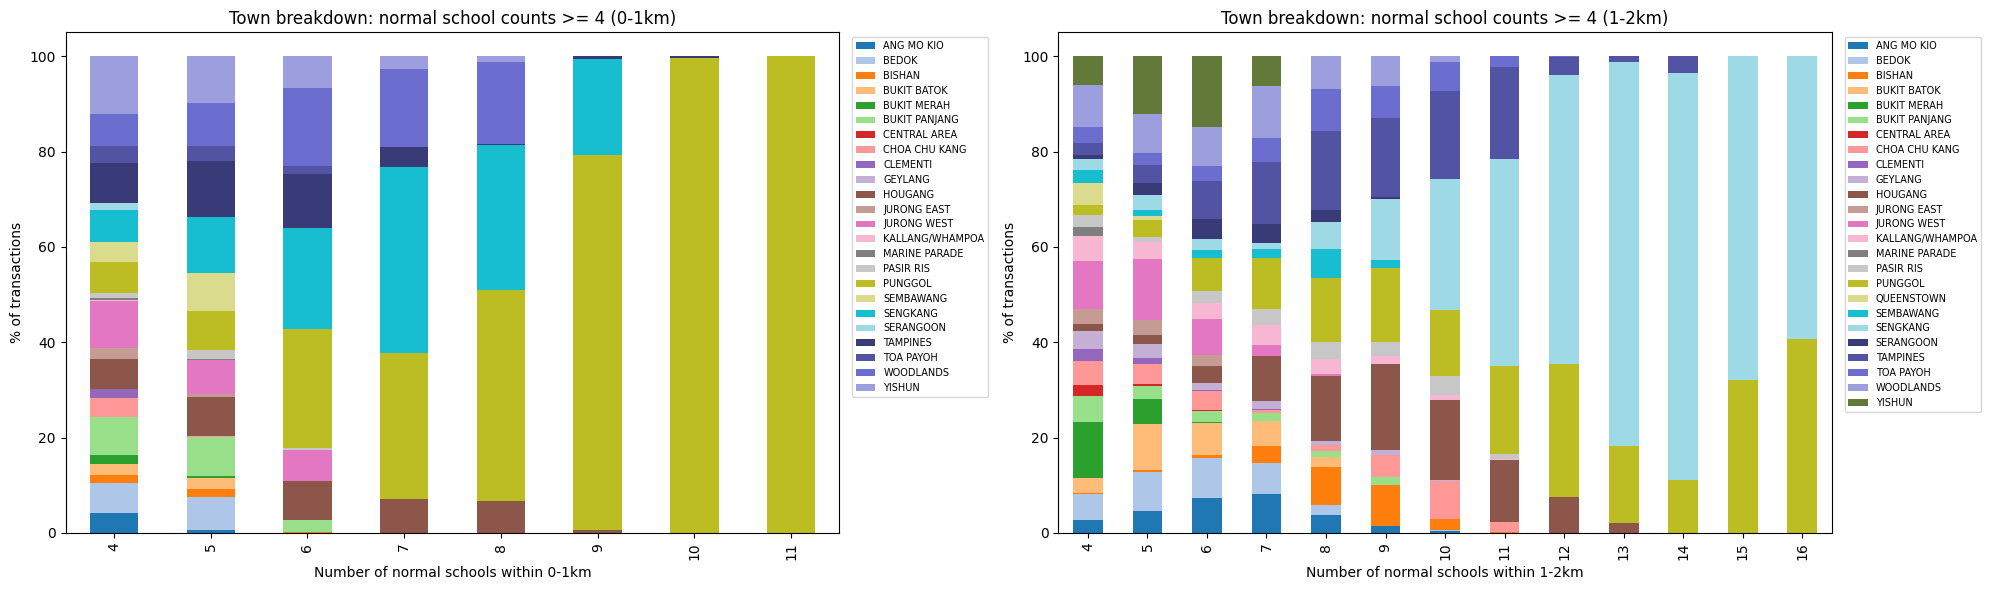

In [88]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, (col, threshold, label) in zip(axes, [
    ('num_schools_0_1km_polygon', 4, '0-1km'),
    ('num_schools_1_2km_polygon', 4, '1-2km'),
]):
    high = resale_df[resale_df[col] >= threshold]
    ct = pd.crosstab(high[col], high['town'])
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    n = len(pct.columns)
    colors = (list(cm.tab20.colors) + list(cm.tab20b.colors))[:n]
    pct.plot(kind='bar', stacked=True, ax=ax, color=colors, legend=False)
    ax.set_xlabel(f'Number of normal schools within {label}')
    ax.set_ylabel('% of transactions')
    ax.set_title(f'Town breakdown: normal school counts >= {threshold} ({label})')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

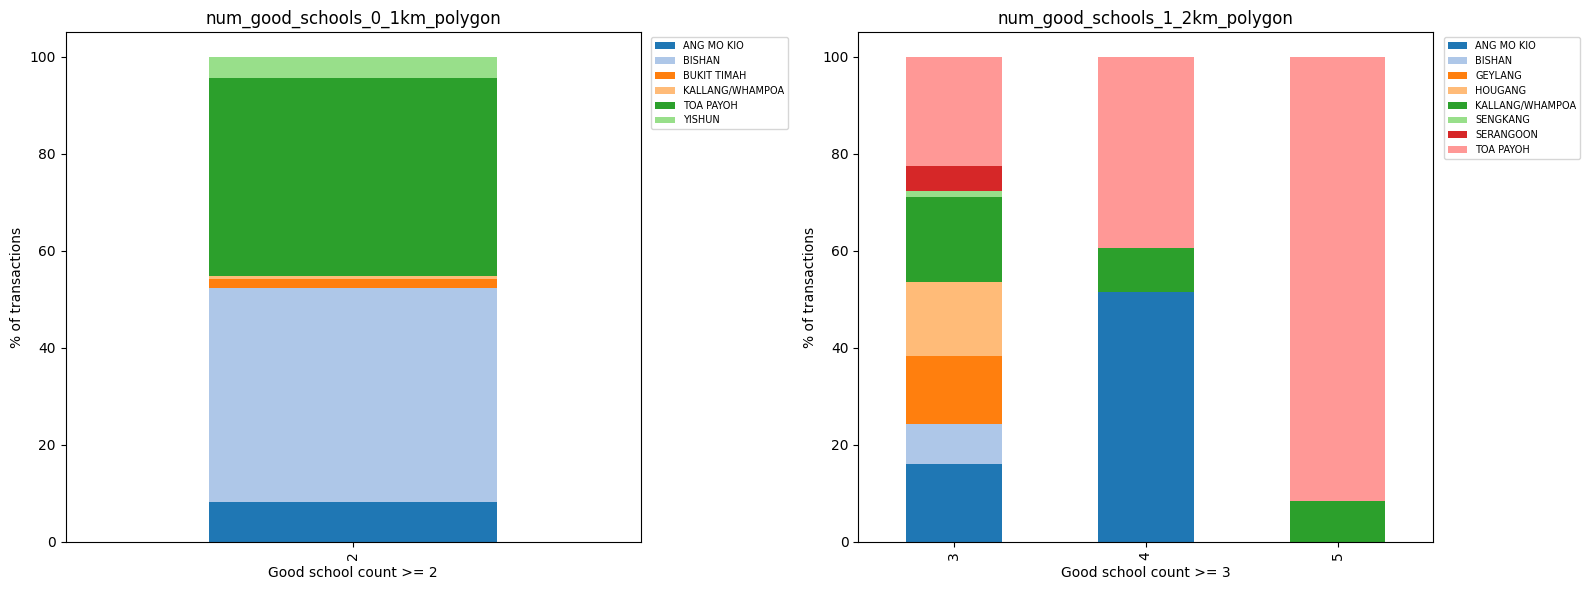

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, threshold) in zip(axes, [
    ('num_good_schools_0_1km_polygon', 2),
    ('num_good_schools_1_2km_polygon', 3)
]):
    high = resale_df[resale_df[col] >= threshold]
    ct = pd.crosstab(high[col], high['town'])
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    n = len(pct.columns)
    colors = (list(cm.tab20.colors) + list(cm.tab20b.colors))[:n]
    pct.plot(kind='bar', stacked=True, ax=ax, color=colors, legend=False)
    ax.set_xlabel(f'Good school count >= {threshold}')
    ax.set_ylabel('% of transactions')
    ax.set_title(col)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

In [91]:
# =========================================================
# 1) PREP SCHOOL DATA
# =========================================================
school_boundary_gdf["start_year"] = pd.to_numeric(
    school_boundary_gdf["start_year"], errors="coerce"
)
school_boundary_gdf["end_year"] = pd.to_numeric(
    school_boundary_gdf["end_year"], errors="coerce"
).fillna(np.inf)

# Point version of each school
school_boundary_gdf["point_geom"] = gpd.GeoSeries(
    gpd.points_from_xy(school_boundary_gdf["X"], school_boundary_gdf["Y"]),
    crs="EPSG:3414"
)

# Keep only good schools for this exercise
good_school_boundary_gdf = school_boundary_gdf[
    school_boundary_gdf["good_school"]
].copy()

# Make sure resale year is numeric
resale_gdf["year"] = pd.to_numeric(resale_gdf["year"], errors="coerce")
resale_gdf = resale_gdf[resale_gdf["year"].notna()].copy()
resale_gdf["year"] = resale_gdf["year"].astype(int)

In [92]:
# =========================================================
# 2) HELPER
# =========================================================
def combine_geoms(geoms):
    """
    Robust union helper for shapely/geopandas versions.
    """
    try:
        return geoms.union_all()
    except AttributeError:
        return geoms.unary_union

Main Step to Create Data for each school

In [93]:
# =========================================================
# 3) MAIN FUNCTION
# =========================================================
def collect_houses_near_good_schools(
    resale_gdf,
    good_school_boundary_gdf,
    school_names=None,
    cutoff_year=2022,
    max_dist=4000
):
    """
    Returns a long GeoDataFrame:
    one row = one resale flat x one good school

    Keeps only rows where the flat is within 0-4 km of that school
    using:
      - polygon distance if year >= cutoff_year
      - xy distance if year < cutoff_year

    Important:
    Distance-band logic matches your old code exactly:
      (dist > min_dist) & (dist <= max_dist)
    so exact distance == 0 is excluded.
    """

    if school_names is None:
        school_names = sorted(
            good_school_boundary_gdf["school_name"].dropna().unique()
        )

    out = []

    for school_name in school_names:
        sch = good_school_boundary_gdf[
            good_school_boundary_gdf["school_name"] == school_name
        ].copy()

        if sch.empty:
            continue

        per_school_chunks = []

        # Loop by resale year so active-school filtering matches your earlier logic
        for yr in sorted(resale_gdf["year"].unique()):
            houses_y = resale_gdf[resale_gdf["year"] == yr].copy()
            if houses_y.empty:
                continue

            active = sch[
                (sch["start_year"] <= yr) &
                (yr <= sch["end_year"])
            ].copy()

            if active.empty:
                continue

            # If more than one active record exists for the same school/year,
            # take min distance via unioned geometry
            poly_union = combine_geoms(active.geometry)
            point_union = combine_geoms(active["point_geom"])

            # Raw distances under BOTH approaches
            houses_y["dist_polygon_m"] = houses_y.geometry.distance(poly_union)
            houses_y["dist_xy_m"] = houses_y.geometry.distance(point_union)

            # -------------------------------------------------
            # BOTH 0-1km binaries (requested explicitly)
            # same exact logic as your old functions
            # -------------------------------------------------
            houses_y["within_0_1km_polygon"] = (
                (houses_y["dist_polygon_m"] > 0) &
                (houses_y["dist_polygon_m"] <= 1000)
            ).astype(int)

            houses_y["within_0_1km_xy"] = (
                (houses_y["dist_xy_m"] > 0) &
                (houses_y["dist_xy_m"] <= 1000)
            ).astype(int)

            # mismatch flag for 0-1km binary
            houses_y["within_0_1km_mismatch"] = (
                houses_y["within_0_1km_polygon"] != houses_y["within_0_1km_xy"]
            ).astype(int)

            # -------------------------------------------------
            # choose approach based on year
            # -------------------------------------------------
            use_polygon = houses_y["year"] >= cutoff_year

            houses_y["approach_used"] = np.where(use_polygon, "polygon", "xy")

            houses_y["distance_to_school_m"] = np.where(
                use_polygon,
                houses_y["dist_polygon_m"],
                houses_y["dist_xy_m"]
            )

            # Requested binaries under selected approach
            houses_y["within_0_1km"] = np.where(
                use_polygon,
                houses_y["within_0_1km_polygon"],
                houses_y["within_0_1km_xy"]
            )

            houses_y["within_0_2km"] = np.where(
                use_polygon,
                (
                    (houses_y["dist_polygon_m"] > 0) &
                    (houses_y["dist_polygon_m"] <= 2000)
                ).astype(int),
                (
                    (houses_y["dist_xy_m"] > 0) &
                    (houses_y["dist_xy_m"] <= 2000)
                ).astype(int)
            )

            # Additional bands you asked for
            houses_y["within_1_2km"] = np.where(
                use_polygon,
                (
                    (houses_y["dist_polygon_m"] > 1000) &
                    (houses_y["dist_polygon_m"] <= 2000)
                ).astype(int),
                (
                    (houses_y["dist_xy_m"] > 1000) &
                    (houses_y["dist_xy_m"] <= 2000)
                ).astype(int)
            )

            houses_y["within_2_3km"] = np.where(
                use_polygon,
                (
                    (houses_y["dist_polygon_m"] > 2000) &
                    (houses_y["dist_polygon_m"] <= 3000)
                ).astype(int),
                (
                    (houses_y["dist_xy_m"] > 2000) &
                    (houses_y["dist_xy_m"] <= 3000)
                ).astype(int)
            )

            houses_y["within_3_4km"] = np.where(
                use_polygon,
                (
                    (houses_y["dist_polygon_m"] > 3000) &
                    (houses_y["dist_polygon_m"] <= 4000)
                ).astype(int),
                (
                    (houses_y["dist_xy_m"] > 3000) &
                    (houses_y["dist_xy_m"] <= 4000)
                ).astype(int)
            )

            # tracking column
            houses_y["target_school_name"] = school_name

            # rounded continuous distance
            houses_y["distance_to_school_m"] = houses_y["distance_to_school_m"].round(2)

            # keep only houses in the 0-4km range under the selected approach
            houses_y = houses_y[
                (houses_y["distance_to_school_m"] > 0) &
                (houses_y["distance_to_school_m"] <= max_dist)
            ].copy()

            if not houses_y.empty:
                per_school_chunks.append(houses_y)

        if per_school_chunks:
            out.append(pd.concat(per_school_chunks, ignore_index=True))

    if not out:
        return gpd.GeoDataFrame(columns=resale_gdf.columns, geometry="geometry", crs=resale_gdf.crs)

    final_df = pd.concat(out, ignore_index=True)
    final_gdf = gpd.GeoDataFrame(final_df, geometry="geometry", crs=resale_gdf.crs)
    return final_gdf

In [ ]:
# all currently flagged good schools
good_school_list = sorted(
    good_school_boundary_gdf["school_name"].dropna().unique()
)


houses_near_good_schools = collect_houses_near_good_schools(
    resale_gdf=resale_gdf,
    good_school_boundary_gdf=good_school_boundary_gdf,
    school_names=good_school_list,   # later to replace with a subset to select schools from the 30 schools, subset_good_schools
    cutoff_year=2022,
    max_dist=3000
)

print(houses_near_good_schools.shape)
houses_near_good_schools.head()

(555503, 39)


,month,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease,address,...,within_0_1km_xy,within_0_1km_mismatch,approach_used,distance_to_school_m,within_0_1km,within_0_2km,within_1_2km,within_2_3km,within_3_4km,target_school_name
0,1,ANG MO KIO,3 ROOM,07 TO 09,60.0,Improved,1986,255000.0,840,174 ANG MO KIO AVE 4,...,0,0,xy,1684.51,0,1,1,0,0,AI TONG SCHOOL
1,1,ANG MO KIO,3 ROOM,01 TO 03,68.0,New Generation,1981,275000.0,780,541 ANG MO KIO AVE 10,...,0,0,xy,2915.79,0,0,0,1,0,AI TONG SCHOOL
2,1,ANG MO KIO,3 ROOM,01 TO 03,69.0,New Generation,1980,285000.0,768,163 ANG MO KIO AVE 4,...,0,0,xy,1544.19,0,1,1,0,0,AI TONG SCHOOL
3,1,ANG MO KIO,3 ROOM,01 TO 03,68.0,New Generation,1979,290000.0,756,446 ANG MO KIO AVE 10,...,0,0,xy,2609.44,0,0,0,1,0,AI TONG SCHOOL
4,1,ANG MO KIO,3 ROOM,07 TO 09,67.0,New Generation,1980,290000.0,768,603 ANG MO KIO AVE 5,...,0,0,xy,2190.44,0,0,0,1,0,AI TONG SCHOOL


In [95]:
reverse_cases = houses_near_good_schools[
    (houses_near_good_schools["within_0_1km_xy"] == 1) &
    (houses_near_good_schools["within_0_1km_polygon"] == 0)
]

print("Reverse cases (xy=1, polygon=0):", len(reverse_cases))

Reverse cases (xy=1, polygon=0): 0


Checking how many houses data close to > 1 good school

In [96]:
house_key_cols = resale_df.columns.tolist()

match_counts = (
    houses_near_good_schools
    .groupby(house_key_cols, dropna=False)
    .size()
    .reset_index(name="n_school_matches")
)

repeat_houses = match_counts[match_counts["n_school_matches"] > 1].copy()

print("Unique resale transactions matched to >1 school:", len(repeat_houses))
print("Total matched rows contributed by these repeated transactions:", repeat_houses["n_school_matches"].sum())
print("Extra matches beyond the first:", (repeat_houses["n_school_matches"] - 1).sum())

## only 111,825 out of 280k schools are close to only one school 

Unique resale transactions matched to >1 school: 160975
Total matched rows contributed by these repeated transactions: 488764
Extra matches beyond the first: 327789


See which schools these repeated houses are close to

In [97]:
repeat_house_school_map = (
    houses_near_good_schools
    .merge(
        repeat_houses[house_key_cols + ["n_school_matches"]],
        on=house_key_cols,
        how="inner"
    )
    .groupby(house_key_cols, dropna=False)
    .agg(
        n_school_matches=("target_school_name", "nunique"),
        schools_close_to=("target_school_name", lambda x: sorted(pd.unique(x.dropna())))
    )
    .reset_index()
)

print(repeat_house_school_map.head())

   month        town flat_type storey_range  floor_area_sqm flat_model  \
0      1  ANG MO KIO    2 ROOM     01 TO 03            44.0   Improved   
1      1  ANG MO KIO    2 ROOM     01 TO 03            44.0   Improved   
2      1  ANG MO KIO    2 ROOM     01 TO 03            45.0   Improved   
3      1  ANG MO KIO    2 ROOM     01 TO 03            45.0   Improved   
4      1  ANG MO KIO    2 ROOM     04 TO 06            44.0   Improved   

   lease_commence_date  resale_price  remaining_lease                address  \
0                 1978      240000.0              732   116 ANG MO KIO AVE 4   
1                 1979      267000.0              665  406 ANG MO KIO AVE 10   
2                 1986      211000.0              769   170 ANG MO KIO AVE 4   
3                 1986      289800.0              745   170 ANG MO KIO AVE 4   
4                 1978      280000.0              649   314 ANG MO KIO AVE 3   

   ...  num_schools_0_1km_polygon  num_schools_0_1km_xy  \
0  ...         

Which schools appear the most among repeated houses

In [98]:
repeat_rows = houses_near_good_schools.merge(
    repeat_houses[house_key_cols],
    on=house_key_cols,
    how="inner"
)

school_overlap_counts = (
    repeat_rows[house_key_cols + ["target_school_name"]]
    .drop_duplicates()
    ["target_school_name"]
    .value_counts()
    .reset_index()
)

school_overlap_counts.columns = ["school_name", "n_repeated_transactions"]
print(school_overlap_counts)

                                school_name  n_repeated_transactions
0                             ROSYTH SCHOOL                    35700
1                  NAN CHIAU PRIMARY SCHOOL                    28285
2            HOLY INNOCENTS' PRIMARY SCHOOL                    27829
3     KUO CHUAN PRESBYTERIAN PRIMARY SCHOOL                    27188
4                       RED SWASTIKA SCHOOL                    25391
5                      CATHOLIC HIGH SCHOOL                    24432
6                     RULANG PRIMARY SCHOOL                    23519
7                ST. HILDA'S PRIMARY SCHOOL                    22725
8                    PEI CHUN PUBLIC SCHOOL                    22612
9         PRINCESS ELIZABETH PRIMARY SCHOOL                    21294
10                 MARIS STELLA HIGH SCHOOL                    19603
11                           CHONGFU SCHOOL                    18691
12                 NORTHLAND PRIMARY SCHOOL                    18682
13                           AI TO

Double checking step to ensure no duplicate pairs

In [99]:
house_key_cols = resale_df.columns.tolist()

pair_level = (
    houses_near_good_schools
    .groupby(house_key_cols + ["target_school_name"], dropna=False)
    .agg(
        within_0_1km=("within_0_1km", "max"),
        within_0_2km=("within_0_2km", "max"),
        within_1_2km=("within_1_2km", "max"),
        distance_to_school_m=("distance_to_school_m", "min")
    )
    .reset_index()
)

Count schools by distance band for each house

In [100]:
house_distance_summary = (
    pair_level
    .groupby(house_key_cols, dropna=False)
    .agg(
        n_schools_0_1km=("within_0_1km", "sum"),
        n_schools_1_2km=("within_1_2km", "sum"),
        n_schools_0_2km=("within_0_2km", "sum"),
        nearest_school_dist_m=("distance_to_school_m", "min")
    )
    .reset_index()
)

print(house_distance_summary.head())

   month        town flat_type storey_range  floor_area_sqm flat_model  \
0      1  ANG MO KIO    2 ROOM     01 TO 03            44.0   Improved   
1      1  ANG MO KIO    2 ROOM     01 TO 03            44.0   Improved   
2      1  ANG MO KIO    2 ROOM     01 TO 03            45.0   Improved   
3      1  ANG MO KIO    2 ROOM     01 TO 03            45.0   Improved   
4      1  ANG MO KIO    2 ROOM     04 TO 06            44.0   Improved   

   lease_commence_date  resale_price  remaining_lease                address  \
0                 1978      240000.0              732   116 ANG MO KIO AVE 4   
1                 1979      267000.0              665  406 ANG MO KIO AVE 10   
2                 1986      211000.0              769   170 ANG MO KIO AVE 4   
3                 1986      289800.0              745   170 ANG MO KIO AVE 4   
4                 1978      280000.0              649   314 ANG MO KIO AVE 3   

   ...  num_schools_1_2km_polygon  num_schools_1_2km_xy  \
0  ...         

In [101]:
combo_table = (
    house_distance_summary
    .groupby(["n_schools_0_1km", "n_schools_1_2km"], dropna=False)
    .size()
    .reset_index(name="n_houses")
    .sort_values(["n_schools_0_1km", "n_schools_1_2km"])
)

print(combo_table)

    n_schools_0_1km  n_schools_1_2km  n_houses
0                 0                0     44655
1                 0                1     59469
2                 0                2     23874
3                 0                3      6764
4                 0                4       865
5                 1                0     52499
6                 1                1     25010
7                 1                2      6326
8                 1                3      3827
9                 1                4       431
10                1                5        86
11                2                0       250
12                2                1      1018
13                2                2      2572
14                2                3        68


Check for number of mismatches from 2022 policy

In [102]:
house_key_cols = resale_df.columns.tolist()

# one row per original resale transaction
house_mismatch = (
    houses_near_good_schools
    .groupby(house_key_cols, dropna=False)
    .agg(has_mismatch=("within_0_1km_mismatch", "max"))
    .reset_index()
)

# total number of houses with mismatch
n_mismatch_houses = house_mismatch["has_mismatch"].sum()
print("Number of houses with mismatch:", n_mismatch_houses)

# split by year
pre2022_mismatch = house_mismatch.loc[
    (house_mismatch["year"] < 2022) & (house_mismatch["has_mismatch"] == 1)
].shape[0]

post2022_mismatch = house_mismatch.loc[
    (house_mismatch["year"] >= 2022) & (house_mismatch["has_mismatch"] == 1)
].shape[0]

print("Mismatch houses, year < 2022 :", pre2022_mismatch)
print("Mismatch houses, year >= 2022:", post2022_mismatch)

Number of houses with mismatch: 13639
Mismatch houses, year < 2022 : 7963
Mismatch houses, year >= 2022: 5676


Deeper Mismatch Testings -- exact same flat checks

In [103]:
same_house_cols = [
    "town",
    "address",
    "flat_type",
    "storey_range",
    "floor_area_sqm",
    "flat_model",
    "lease_commence_date"
]

In [104]:
resale_df.columns

Index(['month', 'town', 'flat_type', 'storey_range', 'floor_area_sqm',
       'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease',
       'address', 'year', 'latitude', 'longitude', 'geometry', 'Date',
       'num_nearby_malls', 'num_nearby_mrt', 'num_unique_mrt_lines',
       'num_schools_0_1km_polygon', 'num_schools_0_1km_xy',
       'num_schools_1_2km_polygon', 'num_schools_1_2km_xy',
       'num_good_schools_0_1km_polygon', 'num_good_schools_0_1km_xy',
       'num_good_schools_1_2km_polygon', 'num_good_schools_1_2km_xy'],
      dtype='object')

In [105]:
# --------------------------------------------------
# 1) one row per resale transaction with 1km count
# --------------------------------------------------
house_key_cols = resale_df.columns.tolist()

tx_1km = (
    houses_near_good_schools
    .groupby(house_key_cols, dropna=False)
    .agg(
        n_schools_0_1km=("within_0_1km", "sum")
    )
    .reset_index()
)

tx_1km["period"] = np.where(tx_1km["year"] < 2022, "pre2022", "post2022")

# --------------------------------------------------
# 2) define same physical house columns explicitly
# --------------------------------------------------
same_house_cols = [
    "town",
    "address",
    "flat_type",
    "storey_range",
    "floor_area_sqm",
    "flat_model",
    "lease_commence_date"
]

def unique_sorted_ints(x):
    vals = pd.Series(x).dropna().astype(int).unique().tolist()
    return sorted(vals)

# --------------------------------------------------
# 3) summarize by house x period
# --------------------------------------------------
house_period = (
    tx_1km
    .groupby(same_house_cols + ["period"], dropna=False)
    .agg(
        n_transactions=("n_schools_0_1km", "size"),
        counts_seen=("n_schools_0_1km", unique_sorted_ints),
        min_1km=("n_schools_0_1km", "min"),
        max_1km=("n_schools_0_1km", "max")
    )
    .reset_index()
)

# --------------------------------------------------
# 4) reshape to pre/post wide format
# --------------------------------------------------
pre = (
    house_period[house_period["period"] == "pre2022"]
    .drop(columns="period")
    .rename(columns={
        "n_transactions": "pre_n_transactions",
        "counts_seen": "pre_counts_seen",
        "min_1km": "pre_min_1km",
        "max_1km": "pre_max_1km"
    })
)

post = (
    house_period[house_period["period"] == "post2022"]
    .drop(columns="period")
    .rename(columns={
        "n_transactions": "post_n_transactions",
        "counts_seen": "post_counts_seen",
        "min_1km": "post_min_1km",
        "max_1km": "post_max_1km"
    })
)

house_pre_post_status = pre.merge(post, on=same_house_cols, how="outer", indicator=True)

# --------------------------------------------------
# 5) classify whether house appears in both / only pre / only post
# --------------------------------------------------
house_pre_post_status["house_status"] = house_pre_post_status["_merge"].map({
    "both": "both_pre_post",
    "left_only": "only_pre",
    "right_only": "only_post"
})

# combined group flags
house_pre_post_status["flag_pre0_post1"] = (
    (house_pre_post_status["house_status"] == "both_pre_post") &
    (house_pre_post_status["pre_max_1km"] == 0) &
    (house_pre_post_status["post_max_1km"] == 1)
).astype(int)

house_pre_post_status["flag_pre0_post2plus"] = (
    (house_pre_post_status["house_status"] == "both_pre_post") &
    (house_pre_post_status["pre_max_1km"] == 0) &
    (house_pre_post_status["post_max_1km"] >= 2)
).astype(int)

# optional: for only-pre / only-post houses, flag what their observed max was
house_pre_post_status["flag_only_pre_zero"] = (
    (house_pre_post_status["house_status"] == "only_pre") &
    (house_pre_post_status["pre_max_1km"] == 0)
).astype(int)

house_pre_post_status["flag_only_pre_oneplus"] = (
    (house_pre_post_status["house_status"] == "only_pre") &
    (house_pre_post_status["pre_max_1km"] >= 1)
).astype(int)

house_pre_post_status["flag_only_post_zero"] = (
    (house_pre_post_status["house_status"] == "only_post") &
    (house_pre_post_status["post_max_1km"] == 0)
).astype(int)

house_pre_post_status["flag_only_post1"] = (
    (house_pre_post_status["house_status"] == "only_post") &
    (house_pre_post_status["post_max_1km"] == 1)
).astype(int)

house_pre_post_status["flag_only_post2plus"] = (
    (house_pre_post_status["house_status"] == "only_post") &
    (house_pre_post_status["post_max_1km"] >= 2)
).astype(int)

# --------------------------------------------------
# 6) summaries
# --------------------------------------------------
print(house_pre_post_status["house_status"].value_counts(dropna=False))

print("Both pre/post with pre=0 and post=1:",
      house_pre_post_status["flag_pre0_post1"].sum())

print("Both pre/post with pre=0 and post>=2:",
      house_pre_post_status["flag_pre0_post2plus"].sum())

print("Only pre houses with 0 schools within 1km:",
      house_pre_post_status["flag_only_pre_zero"].sum())

print("Only pre houses with >=1 school within 1km:",
      house_pre_post_status["flag_only_pre_oneplus"].sum())

print("Only post houses with 0 schools within 1km:",
      house_pre_post_status["flag_only_post_zero"].sum())

print("Only post houses with exactly 1 school within 1km:",
      house_pre_post_status["flag_only_post1"].sum())

print("Only post houses with >=2 schools within 1km:",
      house_pre_post_status["flag_only_post2plus"].sum())

house_status
both_pre_post    34797
only_pre         30945
only_post        21119
Name: count, dtype: int64
Both pre/post with pre=0 and post=1: 1663
Both pre/post with pre=0 and post>=2: 7
Only pre houses with 0 schools within 1km: 19256
Only pre houses with >=1 school within 1km: 11689
Only post houses with 0 schools within 1km: 12240
Only post houses with exactly 1 school within 1km: 8369
Only post houses with >=2 schools within 1km: 510


Listing Down the (Extended) List of Good Schools - 29 Schools

In [107]:
good_school_df = pd.read_csv("../data/processed/schools/school_admissions_no_gep_sap.csv")

In [108]:
school_boundary_gdf["good_school"] = school_boundary_gdf["school_name"].isin(
    good_school_df["School"]
)

good_school_list = sorted(
    school_boundary_gdf.loc[school_boundary_gdf["good_school"], "school_name"]
    .dropna()
    .unique()
)

for s in good_school_list:
    print(s)

print(f"\nNumber of unique good schools: {len(good_school_list)}")

AI TONG SCHOOL
ANGLO-CHINESE SCHOOL (JUNIOR)
ANGLO-CHINESE SCHOOL (PRIMARY)
CATHOLIC HIGH SCHOOL
CHIJ PRIMARY (TOA PAYOH)
CHIJ ST. NICHOLAS GIRLS' SCHOOL
CHONGFU SCHOOL
FAIRFIELD METHODIST SCHOOL (PRIMARY)
FRONTIER PRIMARY SCHOOL
HOLY INNOCENTS' PRIMARY SCHOOL
KONG HWA SCHOOL
KUO CHUAN PRESBYTERIAN PRIMARY SCHOOL
MAHA BODHI SCHOOL
MARIS STELLA HIGH SCHOOL
METHODIST GIRLS' SCHOOL (PRIMARY)
NAN CHIAU PRIMARY SCHOOL
NANYANG PRIMARY SCHOOL
NORTHLAND PRIMARY SCHOOL
PEI CHUN PUBLIC SCHOOL
PEI HWA PRESBYTERIAN PRIMARY SCHOOL
PRINCESS ELIZABETH PRIMARY SCHOOL
RED SWASTIKA SCHOOL
ROSYTH SCHOOL
RULANG PRIMARY SCHOOL
SINGAPORE CHINESE GIRLS' PRIMARY SCHOOL
SOUTH VIEW PRIMARY SCHOOL
ST. HILDA'S PRIMARY SCHOOL
ST. JOSEPH'S INSTITUTION JUNIOR
TAO NAN SCHOOL

Number of unique good schools: 29


### Good School resale data count and normal school resale data count

In [113]:
good_school_resale_counts = (
    houses_near_good_schools
    .groupby('target_school_name')
    .size()
    .reset_index(name='n_resale_transactions')
    .sort_values('n_resale_transactions', ascending=False)
)
print("Good school resale transaction counts:")
print(good_school_resale_counts)

Good school resale transaction counts:
                         target_school_name  n_resale_transactions
15                 NAN CHIAU PRIMARY SCHOOL                  49945
22                            ROSYTH SCHOOL                  35758
26               ST. HILDA'S PRIMARY SCHOOL                  31914
9            HOLY INNOCENTS' PRIMARY SCHOOL                  27868
11    KUO CHUAN PRESBYTERIAN PRIMARY SCHOOL                  27219
21                      RED SWASTIKA SCHOOL                  26523
25                SOUTH VIEW PRIMARY SCHOOL                  24852
3                      CATHOLIC HIGH SCHOOL                  24460
6                            CHONGFU SCHOOL                  23977
20        PRINCESS ELIZABETH PRIMARY SCHOOL                  23970
23                    RULANG PRIMARY SCHOOL                  23547
18                   PEI CHUN PUBLIC SCHOOL                  22638
13                 MARIS STELLA HIGH SCHOOL                  19627
17                 NORT

In [114]:
normal_schools_buf = school_boundary_gdf[~school_boundary_gdf['good_school']][['school_name', 'point_geom']].copy()
normal_schools_buf = gpd.GeoDataFrame(normal_schools_buf, geometry='point_geom', crs='EPSG:3414')
normal_schools_buf['geometry'] = normal_schools_buf.geometry.buffer(1000)  # 1km to match 0-1km band
normal_schools_buf = normal_schools_buf.set_geometry('geometry').drop(columns='point_geom')

joined_normal = gpd.sjoin(
    resale_gdf[['geometry']].reset_index(names='flat_idx'),
    normal_schools_buf[['school_name', 'geometry']],
    how='right',
    predicate='within'
)

normal_school_resale_counts = (
    joined_normal.groupby('school_name')['flat_idx']
    .count()
    .reset_index(name='n_resale_transactions')
    .sort_values('n_resale_transactions', ascending=False)
)
print("Normal school resale transaction counts (within 1km):")
print(normal_school_resale_counts)

Normal school resale transaction counts (within 1km):
                         school_name  n_resale_transactions
41          EDGEFIELD PRIMARY SCHOOL                  13813
84                    MEE TOH SCHOOL                  11821
109      PUNGGOL VIEW PRIMARY SCHOOL                  11595
117         RIVERVALE PRIMARY SCHOOL                  11226
107     PUNGGOL GREEN PRIMARY SCHOOL                  10876
..                               ...                    ...
128  ST. MARGARET'S SCHOOL (PRIMARY)                    456
15        BUKIT TIMAH PRIMARY SCHOOL                    403
133    TANJONG KATONG PRIMARY SCHOOL                    355
27      CHIJ OUR LADY QUEEN OF PEACE                    283
114    RAFFLES GIRLS' PRIMARY SCHOOL                     70

[165 rows x 2 columns]
